# Taller 1 - Punto 1: Regresión lineal
## Predicción de la productividad

**Pontificia Universidad Javeriana - Maestría en Inteligencia Artificial - Aprendizaje de máquina**

Este notebook desarrolla el Taller 1 que predice la **productividad** del cultivo de arroz, definida como:

$$\text{Productividad} = \frac{\text{Paddy yield (in Kg)}}{\text{Hectares}}$$

Se utiliza el dataset [Paddy Dataset](https://archive.ics.uci.edu/dataset/1186/paddy+dataset) de UCI Machine Learning Repository.

## 1. Setup

Importamos únicamente las librerías permitidas por el enunciado.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(50)

## 2. Carga de datos

El dataset se descarga directamente del repositorio de UCI y se carga con pandas.

In [3]:
url = "https://archive.ics.uci.edu/static/public/1186/paddy+dataset.zip"
df = pd.read_csv(url, compression="zip")
df.columns = [c.strip() for c in df.columns]
df.shape

(2789, 45)

In [4]:
df.head()

,Hectares,Agriblock,Variety,Soil Types,Seedrate(in Kg),LP_Mainfield(in Tonnes),Nursery,Nursery area (Cents),LP_nurseryarea(in Tonnes),DAP_20days,...,Wind Direction_D1_D30,Wind Direction_D31_D60,Wind Direction_D61_D90,Wind Direction_D91_D120,Relative Humidity_D1_D30,Relative Humidity_D31_D60,Relative Humidity_D61_D90,Relative Humidity_D91_D120,Trash(in bundles),Paddy yield(in Kg)
0,6,Cuddalore,CO_43,alluvial,150,75.0,dry,120,6,240,...,SW,W,NNW,WSW,72.0,78,88,85,540,35028
1,6,Kurinjipadi,ponmani,clay,150,75.0,wet,120,6,240,...,NW,S,SE,SSE,64.6,85,84,87,600,35412
2,6,Panruti,delux ponni,alluvial,150,75.0,dry,120,6,240,...,ENE,NE,NNE,W,85.0,96,84,79,600,36300
3,6,Kallakurichi,CO_43,clay,150,75.0,wet,120,6,240,...,W,WNW,SE,S,88.5,95,81,84,540,35016
4,6,Sankarapuram,ponmani,alluvial,150,75.0,dry,120,6,240,...,SSE,W,SW,NW,72.7,91,83,81,600,34044


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2789 entries, 0 to 2788
Data columns (total 45 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Hectares                            2789 non-null   int64  
 1   Agriblock                           2789 non-null   str    
 2   Variety                             2789 non-null   str    
 3   Soil Types                          2789 non-null   str    
 4   Seedrate(in Kg)                     2789 non-null   int64  
 5   LP_Mainfield(in Tonnes)             2789 non-null   float64
 6   Nursery                             2789 non-null   str    
 7   Nursery area (Cents)                2789 non-null   int64  
 8   LP_nurseryarea(in Tonnes)           2789 non-null   int64  
 9   DAP_20days                          2789 non-null   int64  
 10  Weed28D_thiobencarb                 2789 non-null   int64  
 11  Urea_40Days                         2789 non-null   fl

No hay valores nulos y las columnas mezclan variables numéricas con variables categóricas.

## 3. Exploración de datos

### 3.1 Creación de la variable objetivo

La variable productividad no existe en el dataset original ya que se construye dividiendo el rendimiento (`Paddy yield(in Kg)`) entre las hectáreas cultivadas (`Hectares`).

In [6]:
df["Productividad"] = df["Paddy yield(in Kg)"] / df["Hectares"]
df = df.drop(columns=["Paddy yield(in Kg)"])
df["Productividad"].describe()

count    2789.000000
mean     5990.531015
std       283.243564
min      5410.000000
25%      5836.000000
50%      5964.000000
75%      6227.000000
max      6469.000000
Name: Productividad, dtype: float64

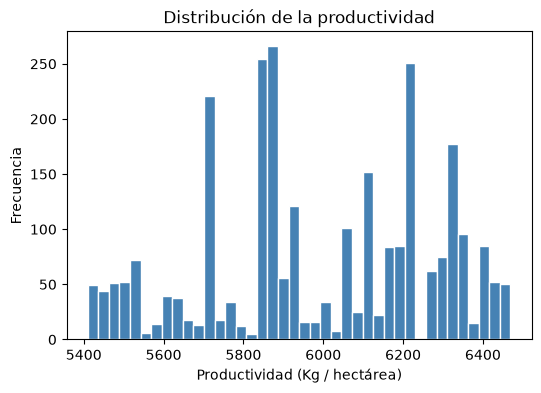

In [7]:
plt.figure(figsize=(6,4))
plt.hist(df["Productividad"], bins=40, color="steelblue", edgecolor="white")
plt.xlabel("Productividad (Kg / hectárea)")
plt.ylabel("Frecuencia")
plt.title("Distribución de la productividad")
plt.show()

### 3.2 Variables categóricas y su distribución

In [8]:
cat_cols = ["Agriblock", "Variety", "Soil Types", "Nursery"]
for c in cat_cols:
    print(df[c].value_counts(), "\n")

Agriblock
Sankarapuram    605
Kurinjipadi     486
Cuddalore       450
Panruti         425
Kallakurichi    413
Chinnasalem     410
Name: count, dtype: int64 

Variety
ponmani        1061
delux ponni     996
CO_43           732
Name: count, dtype: int64 

Soil Types
clay        1521
alluvial    1268
Name: count, dtype: int64 

Nursery
dry    1540
wet    1249
Name: count, dtype: int64 



### 3.3 Correlación de variables numéricas con la productividad

Para orientar la selección de variables se calcula la correlación entre cada variable numérica y la productividad.

In [9]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.drop("Productividad")

def pearson_corr(x, y):
    x = x - x.mean()
    y = y - y.mean()
    return np.sum(x*y) / np.sqrt(np.sum(x**2) * np.sum(y**2))

correlaciones = pd.Series(
    {c: pearson_corr(df[c].values.astype(float), df["Productividad"].values.astype(float)) for c in numeric_cols}
).sort_values(key=np.abs, ascending=False)
correlaciones

Nursery area (Cents)                  0.609589
Pest_60Day(in ml)                     0.609589
Micronutrients_70Days                 0.609589
DAP_20days                            0.609589
LP_Mainfield(in Tonnes)               0.609589
Seedrate(in Kg)                       0.609589
Hectares                              0.609589
LP_nurseryarea(in Tonnes)             0.609589
Potassh_50Days                        0.609589
Weed28D_thiobencarb                   0.609589
Urea_40Days                           0.609589
Trash(in bundles)                     0.564399
Inst Wind Speed_D1_D30(in Knots)      0.033125
Inst Wind Speed_D61_D90(in Knots)     0.024545
Max temp_D61_D90                      0.024203
Min temp_D61_D90                      0.023674
Min temp_D1_D30                       0.023484
Min temp_D31_D60                      0.017799
Max temp_D1_D30                      -0.015986
Relative Humidity_D1_D30             -0.014847
Relative Humidity_D61_D90            -0.014560
30DRain( in m

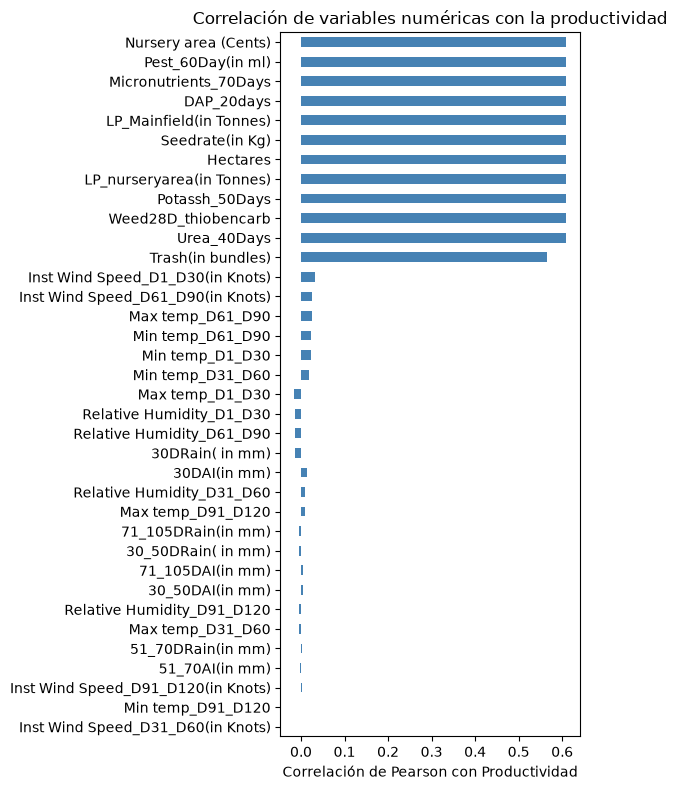

In [10]:
plt.figure(figsize=(6,8))
correlaciones.plot(kind="barh", color="steelblue")
plt.xlabel("Correlación de Pearson con Productividad")
plt.gca().invert_yaxis()
plt.title("Correlación de variables numéricas con la productividad")
plt.tight_layout()
plt.show()

Un grupo de variables agronómicas (`Seedrate`, `LP_Mainfield`, `Nursery area`, `LP_nurseryarea`, `DAP_20days`, `Weed28D_thiobencarb`, `Urea_40Days`, `Potassh_50Days`, `Micronutrients_70Days`, `Pest_60Day`) muestra exactamente la misma correlación (~0.61).

### 3.4 Detección de variables redundantes

In [11]:
dosage_like_cols = [
    "Seedrate(in Kg)", "LP_Mainfield(in Tonnes)", "Nursery area (Cents)", "LP_nurseryarea(in Tonnes)",
    "DAP_20days", "Weed28D_thiobencarb", "Urea_40Days", "Potassh_50Days",
    "Micronutrients_70Days", "Pest_60Day(in ml)",
]
ratio_stats = pd.DataFrame({
    "correlacion_con_Hectares": [pearson_corr(df[c].values.astype(float), df["Hectares"].values.astype(float)) for c in dosage_like_cols],
    "std(variable/Hectares)": [(df[c] / df["Hectares"]).std() for c in dosage_like_cols],
}, index=dosage_like_cols)
ratio_stats

,correlacion_con_Hectares,std(variable/Hectares)
Seedrate(in Kg),1.0,0.000000e+00
LP_Mainfield(in Tonnes),1.0,0.000000e+00
Nursery area (Cents),1.0,0.000000e+00
LP_nurseryarea(in Tonnes),1.0,0.000000e+00
DAP_20days,1.0,0.000000e+00
Weed28D_thiobencarb,1.0,0.000000e+00
Urea_40Days,1.0,2.962803e-15
Potassh_50Days,1.0,3.120933e-15
Micronutrients_70Days,1.0,0.000000e+00
Pest_60Day(in ml),1.0,0.000000e+00


Se confirma que las 10 variables tienen correlación 1.0 con `Hectares` y una desviación estándar de 0 en su razón `variable / Hectares`, es decir, son copias redundantes de `Hectares` bajo otra escala.

Adicionalmente, se revisa `Trash(in bundles)`, que no forma parte de este grupo pero muestra una correlación inusualmente alta con la productividad.

In [12]:
print("Correlación Trash vs Productividad:", pearson_corr(df["Trash(in bundles)"].values.astype(float), df["Productividad"].values.astype(float)))
print("Correlación Trash vs Paddy yield (antes de eliminarlo):", pearson_corr(df["Trash(in bundles)"].values.astype(float), (df["Productividad"]*df["Hectares"]).values.astype(float)))

Correlación Trash vs Productividad: 0.5643990732584759
Correlación Trash vs Paddy yield (antes de eliminarlo): 0.9575959144365856


`Trash(in bundles)` correlaciona 0.56 con la productividad y 0.96 con el rendimiento total (`Paddy yield`), muy por encima del resto de variables climáticas o agronómicas. Siguiendo el mismo criterio aplicado arriba se descarta `Trash(in bundles)` del conjunto de variables predictoras.

In [13]:
df = df.drop(columns=dosage_like_cols + ["Trash(in bundles)"])
df.shape

(2789, 34)

### 3.5 Transformación de variables

In [14]:
wind_cols = [c for c in df.columns if c.startswith("Wind Direction")]
cat_cols_all = cat_cols + wind_cols

df_dummies = pd.get_dummies(df[cat_cols_all], drop_first=True)
df = df.drop(columns=cat_cols_all).join(df_dummies)
df.shape

(2789, 53)

## 4. Partición de datos

Se particiona el dataset en:

* **Train (70%):** para ajustar los parámetros $\theta$.
* **Validation (15%):** para comparar hipótesis e hiperparámetros y seleccionar el modelo.
* **Test (15%):** para estimar el error final sobre datos no vistos, usado únicamente una vez al final.

In [15]:
train_df = df.sample(frac=0.7, random_state=200)
rest_df = df.drop(train_df.index)
val_df = rest_df.sample(frac=0.5, random_state=200)
test_df = rest_df.drop(val_df.index)

train_df.shape, val_df.shape, test_df.shape

((1952, 53), (418, 53), (419, 53))

## 5. Implementación del modelo (NumPy)

Se implementa un modelo de regresión lineal múltiple con descenso de gradiente, función de costo MSE y regularización L2.

In [16]:
def add_bias(X):
    """Agrega la columna constante de 1's (bias) a la matriz de diseño."""
    return np.hstack((np.ones((X.shape[0], 1)), X))


def standardize(X, mu=None, sigma=None):
    """Estandariza X (media 0, desv. estándar 1). mu/sigma se calculan sobre
    train y se reutilizan sobre validation/test para evitar fuga de información."""
    if mu is None:
        mu = X.mean(axis=0)
        sigma = X.std(axis=0)
        sigma = np.where(sigma == 0, 1.0, sigma)
    return (X - mu) / sigma, mu, sigma


def mse_cost(theta, X_c, y, lam=0.0):
    n = X_c.shape[0]
    m = X_c.shape[1] - 1
    error = X_c @ theta - y
    reg = (lam / (2 * m)) * np.sum(theta[1:] ** 2)
    return (1 / (2 * n)) * np.sum(error ** 2) + reg


def fit_model(X_c, y, alpha, epochs, lam=0.0):
    """Descenso de gradiente por lotes, totalmente vectorizado.
    Retorna theta ajustado y el historial de costo (para diagnosticar convergencia)."""
    n, p = X_c.shape
    m = p - 1
    theta = np.zeros((p, 1))
    hist = []
    for i in range(epochs):
        grad = (X_c.T @ (X_c @ theta - y)) / n
        reg_grad = (lam / m) * theta
        reg_grad[0, 0] = 0.0
        theta = theta - alpha * (grad + reg_grad)
        if i % max(1, epochs // 50) == 0:
            hist.append(mse_cost(theta, X_c, y, lam))
    return theta, hist


def rmse(theta, X_c, y):
    error = X_c @ theta - y
    return np.sqrt(np.mean(error ** 2))


### 5.1 Verificación de la implementación

Antes de experimentar, se verifica que el descenso de gradiente efectivamente reduce la función de costo de forma monótona en un caso simple.

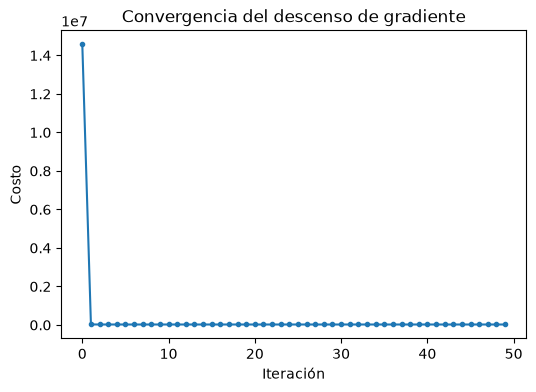

¿Costo estrictamente no creciente? True
theta final: [5989.13985656  171.73899957]


In [17]:
X_check = train_df[["Hectares"]].values.astype(float)
y_check = train_df[["Productividad"]].values.astype(float)
X_check_s, mu_c, sigma_c = standardize(X_check)
X_check_c = add_bias(X_check_s)

theta_check, hist_check = fit_model(X_check_c, y_check, alpha=0.1, epochs=2000, lam=0.0)

plt.figure(figsize=(6,4))
plt.plot(hist_check, marker="o", markersize=3)
plt.xlabel("Iteración")
plt.ylabel("Costo")
plt.title("Convergencia del descenso de gradiente")
plt.show()

print("¿Costo estrictamente no creciente?", all(np.diff(hist_check) <= 1e-8))
print("theta final:", theta_check.ravel())

La curva de costo decrece de forma monótona y se estabiliza, lo que confirma que la implementación del descenso de gradiente y de la función de costo es correcta y numéricamente estable con las variables estandarizadas.

## 6. Experimentación: construcción progresiva de hipótesis

Se comparan cuatro hipótesis de complejidad creciente, evaluadas siempre con el **error de validación** (nunca con test, que se reserva para el final):

* **Modelo A:** solo variables numéricas originales.
* **Modelo B:** A + variables categóricas (`Agriblock`, `Variety`, `Soil Types`, `Nursery`) como dummies.
* **Modelo C:** B + dirección del viento + términos polinómicos (cuadráticos) de variables climáticas relevantes (lluvia, temperatura mínima y humedad relativa de los primeros 30 días).
* **Modelo D:** C + regularización L2, con búsqueda de $\lambda$ sobre una grilla, seleccionando el $\lambda$ que minimiza el error de validación.

En todos los casos las variables se estandarizan usando la media y desviación estándar del **conjunto de entrenamiento**, aplicadas luego a validación y test (para no filtrar información de val/test hacia el ajuste).

In [18]:
base_numeric = [
    "Hectares", "30DRain( in mm)", "30DAI(in mm)", "30_50DRain( in mm)",
    "30_50DAI(in mm)", "51_70DRain(in mm)", "51_70AI(in mm)", "71_105DRain(in mm)", "71_105DAI(in mm)",
    "Min temp_D1_D30", "Max temp_D1_D30", "Min temp_D31_D60", "Max temp_D31_D60", "Min temp_D61_D90",
    "Max temp_D61_D90", "Min temp_D91_D120", "Max temp_D91_D120", "Inst Wind Speed_D1_D30(in Knots)",
    "Inst Wind Speed_D31_D60(in Knots)", "Inst Wind Speed_D61_D90(in Knots)", "Inst Wind Speed_D91_D120(in Knots)",
    "Relative Humidity_D1_D30", "Relative Humidity_D31_D60", "Relative Humidity_D61_D90",
    "Relative Humidity_D91_D120",
]
dummy_cols = list(df_dummies.columns)
key_poly_cols = ["30DRain( in mm)", "Min temp_D1_D30", "Relative Humidity_D1_D30"]

target = "Productividad"
y_train = train_df[[target]].values.astype(float)
y_val = val_df[[target]].values.astype(float)
y_test = test_df[[target]].values.astype(float)


def make_design(cols, poly_cols=None):
    Xtr = train_df[cols].values.astype(float)
    Xval = val_df[cols].values.astype(float)
    Xtest = test_df[cols].values.astype(float)
    if poly_cols:
        Xtr = np.hstack([Xtr, train_df[poly_cols].values.astype(float) ** 2])
        Xval = np.hstack([Xval, val_df[poly_cols].values.astype(float) ** 2])
        Xtest = np.hstack([Xtest, test_df[poly_cols].values.astype(float) ** 2])
    Xtr_s, mu, sigma = standardize(Xtr)
    Xval_s, _, _ = standardize(Xval, mu, sigma)
    Xtest_s, _, _ = standardize(Xtest, mu, sigma)
    return add_bias(Xtr_s), add_bias(Xval_s), add_bias(Xtest_s)

In [19]:
ALPHA, EPOCHS = 0.05, 3000
results = []

Xtr_A, Xval_A, Xtest_A = make_design(base_numeric)
theta_A, _ = fit_model(Xtr_A, y_train, alpha=ALPHA, epochs=EPOCHS, lam=0.0)
results.append(["A: numéricas", 0.0, rmse(theta_A, Xtr_A, y_train), rmse(theta_A, Xval_A, y_val)])

cols_B = base_numeric + dummy_cols
Xtr_B, Xval_B, Xtest_B = make_design(cols_B)
theta_B, _ = fit_model(Xtr_B, y_train, alpha=ALPHA, epochs=EPOCHS, lam=0.0)
results.append(["B: + categóricas", 0.0, rmse(theta_B, Xtr_B, y_train), rmse(theta_B, Xval_B, y_val)])

cols_C = base_numeric + dummy_cols
Xtr_C, Xval_C, Xtest_C = make_design(cols_C, poly_cols=key_poly_cols)
theta_C, _ = fit_model(Xtr_C, y_train, alpha=ALPHA, epochs=EPOCHS, lam=0.0)
results.append(["C: + polinomios", 0.0, rmse(theta_C, Xtr_C, y_train), rmse(theta_C, Xval_C, y_val)])

results_df = pd.DataFrame(results, columns=["Modelo", "lambda", "RMSE train", "RMSE val"])
results_df

,Modelo,lambda,RMSE train,RMSE val
0,A: numéricas,0.0,226.477855,210.532354
1,B: + categóricas,0.0,225.402076,210.547618
2,C: + polinomios,0.0,225.402076,210.547618


### 6.1 Ajuste de la regularización ($\lambda$)

Sobre la hipótesis del **Modelo C**, y usando la tasa de aprendizaje $\alpha$ ya validada en la sección 5.1, se prueban distintos valores de $\lambda$ y se compara el error de validación de cada uno para elegir el que lo minimiza.

In [20]:
best_alpha = ALPHA
lambdas_probar = [0.0, 1.0, 10.0, 50.0, 100.0]

rmse_val_por_lambda = []
for lam in lambdas_probar:
    theta_g, _ = fit_model(Xtr_C, y_train, alpha=best_alpha, epochs=EPOCHS, lam=lam)
    val_err = rmse(theta_g, Xval_C, y_val)
    rmse_val_por_lambda.append(val_err)
    print(f"lambda={lam:>6} -> RMSE train={rmse(theta_g, Xtr_C, y_train):.2f}  RMSE val={val_err:.2f}")

best_lambda = lambdas_probar[int(np.argmin(rmse_val_por_lambda))]
print(f"\nMejor lambda (menor RMSE de validación): {best_lambda}")

lambda=   0.0 -> RMSE train=225.40  RMSE val=210.55
lambda=   1.0 -> RMSE train=225.42  RMSE val=210.76
lambda=  10.0 -> RMSE train=226.95  RMSE val=213.78
lambda=  50.0 -> RMSE train=239.86  RMSE val=229.95
lambda= 100.0 -> RMSE train=251.35  RMSE val=242.81

Mejor lambda (menor RMSE de validación): 0.0


In [21]:
theta_D, hist_D = fit_model(Xtr_C, y_train, alpha=best_alpha, epochs=EPOCHS, lam=best_lambda)
results.append([
    f"D: Ridge (alpha={best_alpha}, lambda={best_lambda})", best_lambda,
    rmse(theta_D, Xtr_C, y_train), rmse(theta_D, Xval_C, y_val),
])
results_df = pd.DataFrame(results, columns=["Modelo", "lambda", "RMSE train", "RMSE val"])
results_df

,Modelo,lambda,RMSE train,RMSE val
0,A: numéricas,0.0,226.477855,210.532354
1,B: + categóricas,0.0,225.402076,210.547618
2,C: + polinomios,0.0,225.402076,210.547618
3,"D: Ridge (alpha=0.05, lambda=0.0)",0.0,225.402076,210.547618


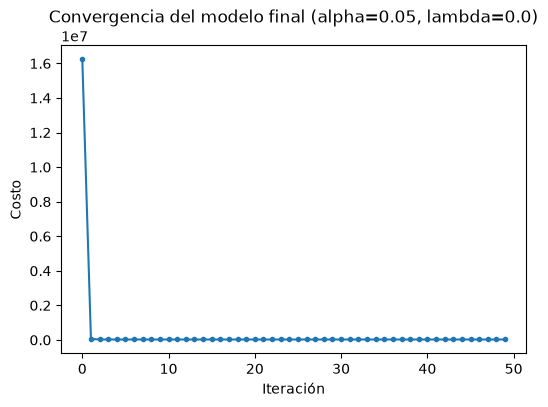

In [22]:
plt.figure(figsize=(6,4))
plt.plot(hist_D, marker="o", markersize=3)
plt.xlabel("Iteración")
plt.ylabel("Costo")
plt.title(f"Convergencia del modelo final (alpha={best_alpha}, lambda={best_lambda})")
plt.show()

### 6.2 Selección del modelo final

Se selecciona como modelo final la hipótesis con **menor RMSE de validación** entre todas las evaluadas.

In [23]:
best_model_row = results_df.loc[results_df["RMSE val"].idxmin()]
best_model_row

Modelo        A: numéricas
lambda                 0.0
RMSE train      226.477855
RMSE val        210.532354
Name: 0, dtype: object

## 7. Evaluación final sobre el conjunto de test

El conjunto de test **no se ha usado hasta este punto** para ninguna decisión de modelado ni de hiperparámetros; se usa una única vez para estimar el error de generalización del modelo final seleccionado (Modelo D, con $\alpha$ y $\lambda$ óptimos de validación).

In [24]:
test_rmse = rmse(theta_D, Xtest_C, y_test)
print(f"RMSE test: {test_rmse:.2f} Kg/ha")
print(f"Media de Productividad: {df[target].mean():.2f} Kg/ha | Desv. estándar: {df[target].std():.2f} Kg/ha")

RMSE test: 228.09 Kg/ha
Media de Productividad: 5990.53 Kg/ha | Desv. estándar: 283.24 Kg/ha


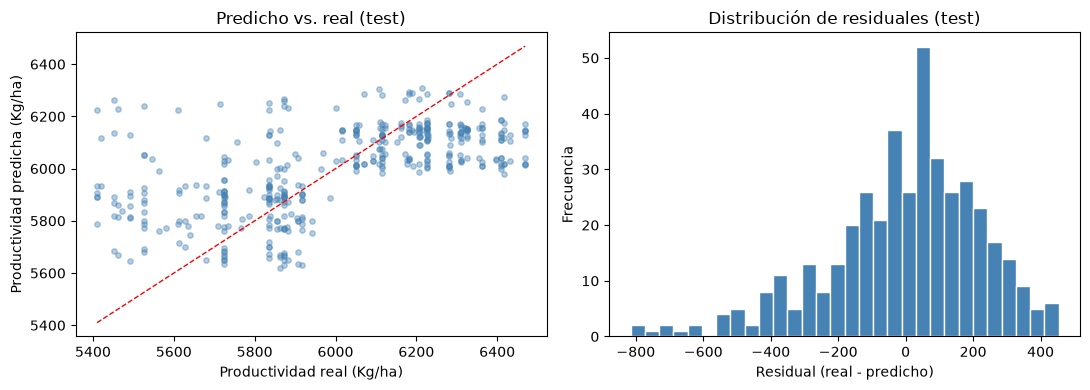

In [ ]:
y_pred_test = Xtest_C @ theta_D

fig, axes = plt.subplots(1, 2, figsize=(11,4))

axes[0].scatter(y_test, y_pred_test, alpha=0.4, s=15, color="steelblue")
lims = [min(y_test.min(), y_pred_test.min()), max(y_test.max(), y_pred_test.max())]
axes[0].plot(lims, lims, color="red", linestyle="--", linewidth=1)
axes[0].set_xlabel("Productividad real (Kg/ha)")
axes[0].set_ylabel("Productividad predicha (Kg/ha)")
axes[0].set_title("Predicho vs. real")

residuals = (y_test - y_pred_test).ravel()
axes[1].hist(residuals, bins=30, color="steelblue", edgecolor="white")
axes[1].set_xlabel("Residual (real - predicho)")
axes[1].set_ylabel("Frecuencia")
axes[1].set_title("Distribución de residuales")

plt.tight_layout()
plt.show()

## 8. Análisis de resultados y conclusiones

**Resultados.** El modelo final alcanza un RMSE de test de **228.09 Kg/ha**, frente a una desviación estándar de la productividad de **~283 Kg/ha**. Es decir, el error del modelo es considerablemente menor que la variabilidad natural de los datos, lo que indica una mejora real sobre predecir siempre la media, aunque sin llegar a un ajuste muy alto.

**Conclusión general.** Se logró implementar y validar correctamente un modelo de regresión lineal con descenso de gradiente vectorizado y regularización L2. La experimentación metódica permitió mejorar progresivamente el modelo.

# Punto 2

## Setup

In [26]:
import pandas as pd
import numpy as np

## Carga de datos

In [27]:
url = "https://archive.ics.uci.edu/static/public/1186/paddy+dataset.zip"
df02 = pd.read_csv(url, compression="zip")

## Exploración de datos

### Limpieza

En esta etapa se realiza una limpieza inicial de la variable objetivo `Variety`.

Primero, se eliminan los registros correspondientes a la variedad `delux ponni`, ya que el modelo de regresión logística se plantea como un problema de **clasificación binaria** y se trabajará únicamente con las variedades `ponmani` y `CO_43`.

Luego, se transformaron la variable categórica `Variety` a valores numéricos:
- `ponmani` → 0
- `CO_43` → 1

Esta transformación permite utilizar `Variety` como variable objetivo dentro del modelo de regresión logística.

In [28]:
df02.drop(df02[df02["Variety"] == "delux ponni"].index, inplace=True)

In [29]:
df02['Variety'] = df02['Variety'].replace({
    'ponmani': 0,
    'CO_43': 1
})

### Correlación

Se calcula la correlación entre las variables predictoras y la variable objetivo `Variety`, con el propósito de identificar qué variables presentan una mayor relación lineal con la clase que se desea predecir.

Los resultados muestran que la mayoría de las variables presentan una correlación cercana a cero con `Variety`. La variable con mayor correlación en valor absoluto es `Trash(in bundles)`, con aproximadamente **-0.13**, aunque esta relación sigue siendo relativamente débil.


In [30]:
numeric_cols = df02.select_dtypes(include=[np.number]).columns.drop("Variety")

def pearson_corr(x, y):
    x = x - x.mean()
    y = y - y.mean()
    return np.sum(x*y) / np.sqrt(np.sum(x**2) * np.sum(y**2))

correlaciones = pd.Series(
    {c: pearson_corr(df02[c].values.astype(float), df02["Variety"].values.astype(float)) for c in numeric_cols}
).sort_values(key=np.abs, ascending=False)
correlaciones

KeyError: "['Variety'] not found in axis"

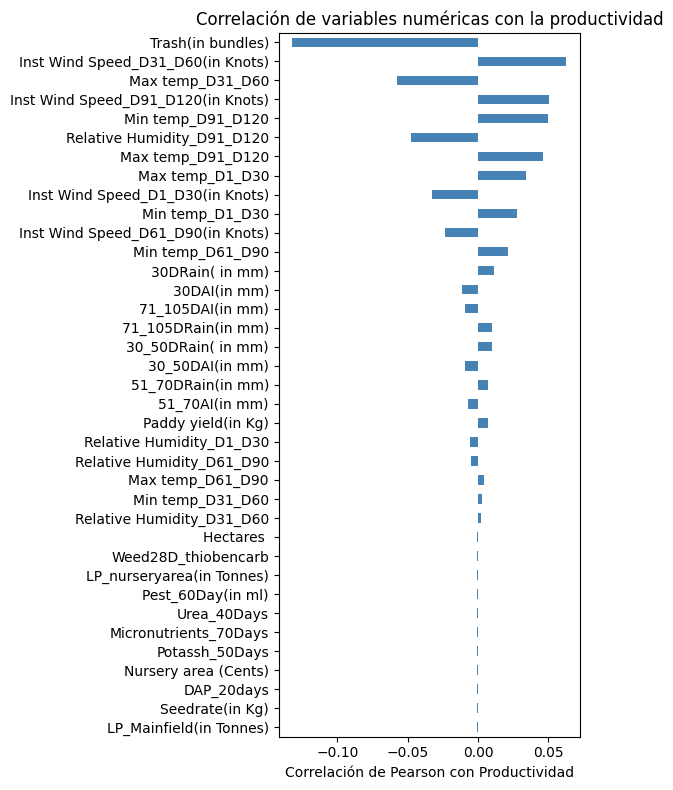

In [ ]:
plt.figure(figsize=(6,8))
correlaciones.plot(kind="barh", color="steelblue")
plt.xlabel("Correlación de Pearson con Productividad")
plt.gca().invert_yaxis()
plt.title("Correlación de variables numéricas con la productividad")
plt.tight_layout()
plt.show()

#### Identificación de variables redundantes

Al analizar la correlación entre algunas variables agrícolas, se observa que presentan una correlación de **1.0 entre sí**.

Esto indica que estas variables contienen información completamente redundante o equivalente dentro del conjunto de datos. Mantener todas estas variables puede introducir redundancia en el modelo.

Por esto, se eliminan las variables:

- `Seedrate(in Kg)`
- `LP_Mainfield(in Tonnes)`
- `Nursery area (Cents)`
- `LP_nurseryarea(in Tonnes)`
- `DAP_20days`

Se conserva `Hectares` como representante de este grupo de variables altamente correlacionadas.

In [ ]:
print(df02[['Hectares ', 'Seedrate(in Kg)', 'LP_Mainfield(in Tonnes)',
            'Nursery area (Cents)', 'LP_nurseryarea(in Tonnes)',
            'DAP_20days']].corr())


                           Hectares   Seedrate(in Kg)  \
Hectares                         1.0              1.0   
Seedrate(in Kg)                  1.0              1.0   
LP_Mainfield(in Tonnes)          1.0              1.0   
Nursery area (Cents)             1.0              1.0   
LP_nurseryarea(in Tonnes)        1.0              1.0   
DAP_20days                       1.0              1.0   

                           LP_Mainfield(in Tonnes)  Nursery area (Cents)  \
Hectares                                       1.0                   1.0   
Seedrate(in Kg)                                1.0                   1.0   
LP_Mainfield(in Tonnes)                        1.0                   1.0   
Nursery area (Cents)                           1.0                   1.0   
LP_nurseryarea(in Tonnes)                      1.0                   1.0   
DAP_20days                                     1.0                   1.0   

                           LP_nurseryarea(in Tonnes)  DAP_20days  


In [ ]:
df02 = df02.drop(columns=[
    'Seedrate(in Kg)',
    'LP_Mainfield(in Tonnes)',
    'Nursery area (Cents)',
    'LP_nurseryarea(in Tonnes)',
    'DAP_20days'
])

### Transformación

En esta etapa se transforman las variables categóricas y las variables relacionadas con la dirección del viento para que puedan ser utilizadas correctamente por el modelo de regresión logística.

Las direcciones del viento están expresadas mediante categorías como `N`, `NE`, `S`, `SW`, etc. Estas categorías tienen una naturaleza circular: por ejemplo, `N` y `NNW` están próximas entre sí, mientras que una codificación numérica convencional podría interpretar incorrectamente estas relaciones.

Por esta razón, cada dirección se convierte primero a grados y posteriormente se transforma mediante las funciones seno y coseno:

$$
x_{sin} = \sin(\theta)
$$

$$
x_{cos} = \cos(\theta)
$$

De esta manera se conserva la naturaleza circular de la dirección del viento y se evita tratarla como una variable categórica ordinaria.

Finalmente, las demás variables categóricas se convierten mediante **One-Hot Encoding**, utilizando `drop_first=True`. Esto crea variables binarias para representar las categorías y elimina una categoría de referencia para evitar redundancia entre las variables generadas.

In [ ]:
compass_to_deg = {
    "N": 0, "NNE": 22.5, "NE": 45, "ENE": 67.5, "E": 90, "ESE": 112.5, "SE": 135, "SSE": 157.5,
    "S": 180, "SSW": 202.5, "SW": 225, "WSW": 247.5, "W": 270, "WNW": 292.5, "NW": 315, "NNW": 337.5,
}

wind_cols = [c for c in df02.columns if c.startswith("Wind Direction")]
for c in wind_cols:
    deg = df02[c].map(compass_to_deg) * np.pi / 180
    df02[c + "_sin"] = np.sin(deg)
    df02[c + "_cos"] = np.cos(deg)
df02 = df02.drop(columns=wind_cols)

df02_dummies = pd.get_dummies(df02[cat_cols], drop_first=True)
df02 = df02.drop(columns=cat_cols).join(df02_dummies)
df02.shape

(1793, 48)

## Partición de datos

Se separan las variables predictoras `X` de la variable objetivo `y`, donde `Variety` representa la clase que el modelo debe predecir.

El conjunto de datos se divide en tres subconjuntos:

- **70 % para entrenamiento:** utilizado para ajustar los parámetros del modelo.
- **15 % para validación:** utilizado para comparar configuraciones y seleccionar el mejor modelo.
- **15 % para prueba:** reservado para realizar la evaluación final sobre datos que el modelo no utilizó durante el entrenamiento ni durante la selección.

Se utiliza `random_state=200` para garantizar que la división sea reproducible y que los mismos registros pertenezcan a cada conjunto cada vez que se ejecute el código.

In [ ]:
X2 = df02.drop(columns=['Variety'])
y2 = df02['Variety']

In [ ]:
train_df2 = df02.sample(frac=0.7, random_state=200)
rest_df2 = df02.drop(train_df2.index)
val_df2 = rest_df2.sample(frac=0.5, random_state=200)
test_df2 = rest_df2.drop(val_df2.index)

In [ ]:
# Crear X e y para train
X_train2 = X2.loc[train_df2.index]
y_train2 = y2.loc[train_df2.index]

# Crear X e y para validation
X_val2 = X2.loc[val_df2.index]
y_val2 = y2.loc[val_df2.index]

# Crear X e y para test
X_test2 = X2.loc[test_df2.index]
y_test2 = y2.loc[test_df2.index]

## Implementación del modelo

En esta sección se implementa manualmente el entrenamiento de una regresión logística utilizando **descenso de gradiente**.

El modelo calcula inicialmente una combinación lineal de las variables:

$$
z = X\theta
$$

donde:

- $X$ representa la matriz de características.
- $\theta$ representa los parámetros o pesos del modelo.
- $z$ representa la combinación lineal de las características.

Para convertir esta combinación lineal en una probabilidad se utiliza la función sigmoide:

$$
\sigma(z) = \frac{1}{1+e^{-z}}
$$

Por lo tanto, la probabilidad estimada de pertenecer a la clase 1 es:

$$
\hat{y} = \sigma(X\theta)
$$

### Función de costo

El error del modelo se mide mediante **Log-Loss** o entropía cruzada binaria:

$$
J(\theta) =
-\frac{1}{n}
\sum_{i=1}^{n}
\left[
y_i\log(\hat{y}_i)
+
(1-y_i)\log(1-\hat{y}_i)
\right]
$$

Esta función penaliza fuertemente las predicciones que asignan una probabilidad incorrecta a la clase real.

Además, el modelo permite incorporar regularización L2:

$$
J_{reg}(\theta)
=
J(\theta)
+
\frac{\lambda}{2n}
\sum_{j=1}^{m}\theta_j^2
$$

La regularización ayuda a evitar que los pesos del modelo tomen valores excesivamente grandes. El término correspondiente al sesgo ($\theta_0$) no se regulariza.

### Actualización de los parámetros

El gradiente de la función de costo se calcula como:

$$
\nabla J(\theta)
=
\frac{1}{n}X^T(\hat{y}-y)
$$

Con regularización:

$$
\nabla J_{reg}(\theta)
=
\frac{1}{n}X^T(\hat{y}-y)
+
\frac{\lambda}{n}\theta
$$

sin aplicar la penalización al término de sesgo.

Finalmente, los parámetros se actualizan mediante descenso de gradiente:

$$
\theta :=
\theta -
\alpha\nabla J_{reg}(\theta)
$$

donde $\alpha$ es la tasa de aprendizaje y determina el tamaño de cada paso realizado durante la optimización.

El proceso se repite durante el número de épocas establecido y se almacena el costo periódicamente para poder analizar la convergencia del algoritmo.

In [ ]:
def fit_model2(X_c, y, alpha, epochs, lam=0.0):
    n, m = X_c.shape
    theta = np.zeros((m, 1))
    hist = []
    for i in range(epochs):
        A = sigmoid(X_c @ theta)
        grad = (X_c.T @ (A - y)) / n
        reg_grad = (lam / n) * theta
        reg_grad[0, 0] = 0.0
        theta = theta - alpha * (grad + reg_grad)
        if i % max(1, epochs // 50) == 0:
            hist.append(log_loss2(theta, X_c, y, lam))
    return theta, hist


def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def log_loss2(theta, X_c, y, lam=0.0):
    n = X_c.shape[0]
    y_hat = sigmoid(X_c @ theta)
    eps = 1e-15
    y_hat = np.clip(y_hat, eps, 1 - eps)
    cost = -np.sum(y * np.log(y_hat) + (1-y) * np.log(1-y_hat)) / n
    reg = (lam / (2*n)) * np.sum(theta[1:]**2)
    return cost + reg

### Varificación de la implementación

Antes de utilizar el modelo completo, se realiza una prueba controlada utilizando únicamente la variable `Hectares`.

El objetivo de esta etapa no es obtener el mejor clasificador, sino **verificar que la implementación del descenso de gradiente funciona correctamente**.

Primero se estandariza la variable:

$$
x' = \frac{x-\mu}{\sigma}
$$

y posteriormente se agrega el término de sesgo para que el modelo pueda aprender el intercepto.

Se entrena el modelo durante 2000 épocas utilizando una tasa de aprendizaje de `0.1` y una regularización de `0.05`.

Finalmente, se registra la función de costo durante el entrenamiento para comprobar que el algoritmo está convergiendo.

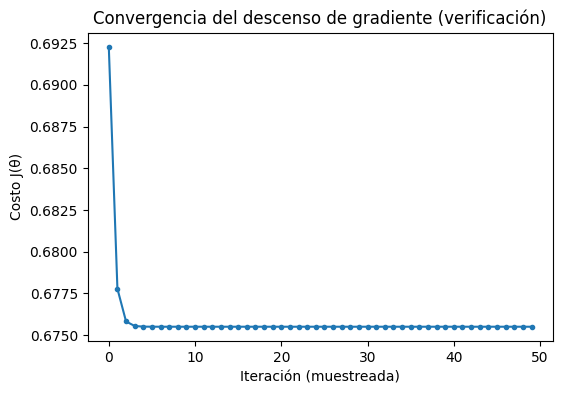

¿Costo estrictamente no creciente? True
theta final: [-0.37897976 -0.00819302]


In [ ]:
X_check2 = train_df2[['Hectares ']].values.astype(float)
y_check2 = train_df2[["Variety"]].values.astype(float)


X_check_s2, mu_c2, sigma_c2 = standardize(X_check2)
X_check_c2 = add_bias(X_check_s2)

theta_check2, hist_check2 = fit_model2(X_check_c2, y_check2, alpha=0.1, epochs=2000, lam=0.05)

plt.figure(figsize=(6,4))
plt.plot(hist_check2, marker="o", markersize=3)
plt.xlabel("Iteración (muestreada)")
plt.ylabel("Costo J(θ)")
plt.title("Convergencia del descenso de gradiente (verificación)")
plt.show()

print("¿Costo estrictamente no creciente?", all(np.diff(hist_check2) <= 1e-8))
print("theta final:", theta_check2.ravel())

## Evaluación del modelo de verificación

Una vez entrenado el modelo de prueba, se calculan las probabilidades predichas mediante la función sigmoide.

Para convertir estas probabilidades en clases se utiliza un umbral de 0.5:

$$
\hat{y} =
\begin{cases}
1 & \text{si } P(y=1|x)\geq0.5\\
0 & \text{si } P(y=1|x)<0.5
\end{cases}
$$

Posteriormente, se construye la matriz de confusión y se calculan Accuracy, Precision, Recall y F1-score.

En esta prueba, el modelo predice todos los registros como clase 0. Esto genera un **Accuracy de aproximadamente 59.36 %**, pero Precision, Recall y F1-score para la clase 1 son iguales a cero.

Este resultado muestra que, aunque el algoritmo de optimización converge correctamente, utilizar únicamente `Hectares` no proporciona suficiente información para distinguir adecuadamente entre las dos variedades.

Es importante diferenciar ambos resultados: la convergencia del algoritmo es correcta, pero el poder predictivo de este modelo de prueba es insuficiente.

In [ ]:
# =========================
# EVALUACIÓN DEL MODELO
# =========================

# 1. Obtener probabilidades predichas por el modelo
probs_check2 = sigmoid(X_check_c2 @ theta_check2)

# 2. Convertir probabilidades a clases 0/1
y_pred_check2 = (probs_check2 >= 0.5).astype(int)

# 3. Matriz de confusión
tp = np.sum((y_check2 == 1) & (y_pred_check2 == 1))
tn = np.sum((y_check2 == 0) & (y_pred_check2 == 0))
fp = np.sum((y_check2 == 0) & (y_pred_check2 == 1))
fn = np.sum((y_check2 == 1) & (y_pred_check2 == 0))

# 4. Métricas
accuracy = (tp + tn) / (tp + tn + fp + fn)
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0
f1 = 2 * precision * recall / (precision + recall) \
if (precision + recall) > 0 else 0

# 5. Log-loss
loss = log_loss2(
    theta_check2,
    X_check_c2,
    y_check2,
    lam=0.05
)

# 6. Mostrar resultados
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1-score :", f1)
print("Log-loss :", loss)

print("\nMatriz de confusión:")
print("              Pred 0    Pred 1")
print("Real 0       ", tn, "       ", fp)
print("Real 1       ", fn, "       ", tp)


Accuracy : 0.5936254980079682
Precision: 0
Recall   : 0.0
F1-score : 0
Log-loss : 0.675503696892995

Matriz de confusión:
              Pred 0    Pred 1
Real 0        745         0
Real 1        510         0


## Construcción progresiva de las hipótesis

Para estudiar cómo influye la selección de variables en el desempeño del modelo, se plantearon inicialmente diferentes modelos de forma progresiva:

- **M1:** `Hectares`
- **M2:** `Hectares` + variables agrícolas
- **M3:** M2 + variables climáticas
- **M4:** M3 + variables categóricas
- **M5:** todas las variables seleccionadas

Esta estrategia permite comparar modelos con diferentes grupos de características y determinar qué tipo de información aporta mayor capacidad predictiva.

Durante la evaluación se encontró un comportamiento inesperado: al combinar `Trash(in bundles)` con cualquiera de las variables agrícolas se obtenía un desempeño del **100 %**.

Este resultado se consideró una señal que debía analizarse con precaución, ya que un desempeño perfecto puede indicar redundancia, una relación extremadamente fuerte entre las variables o incluso una posible fuga de información.

Por esta razón, se modificó la estrategia de construcción de modelos para estudiar por separado el efecto de `Trash` y evitar que su combinación con las variables agrícolas dominara la comparación.


In [ ]:
M1 = [
    'Trash(in bundles)'
]

M2 = [
    'Trash(in bundles)',
    'Inst Wind Speed_D31_D60(in Knots)',
    'Max temp_D31_D60'
]

M3 = [
    'Trash(in bundles)',
    'Inst Wind Speed_D31_D60(in Knots)',
    'Max temp_D31_D60',
    'Inst Wind Speed_D91_D120(in Knots)',
    'Min temp_D91_D120'
]

M4 = [
    'Trash(in bundles)',
    'Inst Wind Speed_D31_D60(in Knots)',
    'Max temp_D31_D60',
    'Inst Wind Speed_D91_D120(in Knots)',
    'Min temp_D91_D120',
    'Relative Humidity_D91_D120',
    'Max temp_D91_D120'
]

M5 = [
    'Trash(in bundles)',
    'Inst Wind Speed_D31_D60(in Knots)',
    'Max temp_D31_D60',
    'Inst Wind Speed_D91_D120(in Knots)',
    'Min temp_D91_D120',
    'Relative Humidity_D91_D120',
    'Max temp_D91_D120',
    'Max temp_D1_D30',
    'Inst Wind Speed_D1_D30(in Knots)',
    'Min temp_D1_D30'
]
modelosx = {"M1": M1,"M2": M2,"M3": M3,"M4": M4,"M5": M5 }

## Nuevas configuraciones de modelos

A partir del comportamiento observado, se construyeron cuatro nuevas configuraciones de variables:

### M1 — Todas las variables excepto `Trash`

Permite evaluar el comportamiento general del conjunto de características sin incluir la variable que produjo el comportamiento perfecto observado anteriormente.

### M2 — Solo `Trash`

Permite determinar cuánto poder predictivo tiene esta variable por sí sola.

### M3 — `Trash` + variables no agrícolas

Se excluyen las variables agrícolas y se conserva `Trash` junto con el resto de variables disponibles.

Este modelo permite evaluar si la información relacionada con factores climáticos y categóricos puede explicar la clasificación sin depender del conjunto de variables agrícolas.

### M4 — Variables con mayor correlación

Se selecciona un grupo reducido de variables que presentan las mayores correlaciones observadas con `Variety`.

Este modelo permite comparar un conjunto pequeño y dirigido de características contra modelos que utilizan una cantidad mayor de variables.


In [ ]:
agricolas = [
    'Hectares ',
    'Weed28D_thiobencarb',
    'Urea_40Days',
    'Potassh_50Days',
    'Micronutrients_70Days',
    'Pest_60Day(in ml)',
    'Seedrate(in Kg)',
    'LP_Mainfield(in Tonnes)',
    'Nursery area (Cents)',
    'LP_nurseryarea(in Tonnes)',
    'DAP_20days'
]
todas = [c for c in X2.columns]

# --------------------------------
# M1: Todas SIN Trash
# --------------------------------
M1 = [
    c for c in todas
    if c != 'Trash(in bundles)'
]

# --------------------------------
# M2: Solo Trash
# --------------------------------
M2 = [
    'Trash(in bundles)'
]

# --------------------------------
# M3: Todas SIN agrícolas + Trash
# --------------------------------
M3 = [
    c for c in todas
    if c not in agricolas
]

# --------------------------------
# M4: Variables más correlacionadas
# --------------------------------
M4 = [
    'Trash(in bundles)',
    'Inst Wind Speed_D31_D60(in Knots)',
    'Max temp_D31_D60',
    'Inst Wind Speed_D91_D120(in Knots)',
    'Min temp_D91_D120',
    'Relative Humidity_D91_D120',
    'Max temp_D91_D120',
    'Max temp_D1_D30',
    'Inst Wind Speed_D1_D30(in Knots)',
    'Min temp_D1_D30'
]
modelos = {"M1": M1,"M2": M2,"M3": M3,"M4": M4}

In [ ]:
resultados = []
alphas = [0.001, 0.01, 0.1]
epochs_list = [1000, 2000, 5000]
lams = [0.0, 0.01, 0.05, 0.1, 1.0]


for nombre, columnas in modelos.items():
    for alpha in alphas:
        for epochs in epochs_list:
            for lam in lams:
                # TRAIN
                X_train = train_df2[columnas].values.astype(float)
                y_train = train_df2[['Variety']].values.astype(float)
                X_train_s, mu, sigma = standardize(X_train)
                X_train_c = add_bias(X_train_s)

                theta, hist = fit_model2(X_train_c,y_train,alpha=alpha,epochs=epochs,lam=lam)

                # VALIDATION
                X_val = val_df2[columnas].values.astype(float)
                y_val = val_df2[['Variety']].values.astype(float)
                X_val_s, _, _ = standardize(X_val, mu, sigma)
                X_val_c = add_bias(X_val_s)
                probs = sigmoid(X_val_c @ theta)
                y_pred = (probs >= 0.5).astype(int)

                tp = np.sum((y_val == 1) & (y_pred == 1))
                tn = np.sum((y_val == 0) & (y_pred == 0))
                fp = np.sum((y_val == 0) & (y_pred == 1))
                fn = np.sum((y_val == 1) & (y_pred == 0))

                accuracy = (tp + tn) / len(y_val)
                precision = tp / (tp + fp) if tp + fp > 0 else 0
                recall = tp / (tp + fn) if tp + fn > 0 else 0
                f1 = 2 * precision * recall / (precision + recall) \
                     if precision + recall > 0 else 0

                resultados.append([nombre, alpha, epochs, lam,accuracy, precision, recall, f1])

resultados_df = pd.DataFrame(resultados,columns=["Modelo", "alpha", "epochs", "lambda","Accuracy", "Precision", "Recall", "F1"])
resultados_df

,Modelo,alpha,epochs,lambda,Accuracy,Precision,Recall,F1
0,M1,0.001,1000,0.00,0.527881,0.398058,0.386792,0.392344
1,M1,0.001,1000,0.01,0.527881,0.398058,0.386792,0.392344
2,M1,0.001,1000,0.05,0.527881,0.398058,0.386792,0.392344
3,M1,0.001,1000,0.10,0.527881,0.398058,0.386792,0.392344
4,M1,0.001,1000,1.00,0.527881,0.398058,0.386792,0.392344
...,...,...,...,...,...,...,...,...
175,M4,0.100,5000,0.00,0.587361,0.441860,0.179245,0.255034
176,M4,0.100,5000,0.01,0.587361,0.441860,0.179245,0.255034
177,M4,0.100,5000,0.05,0.587361,0.441860,0.179245,0.255034
178,M4,0.100,5000,0.10,0.587361,0.441860,0.179245,0.255034


## Selección del mejor modelo y evaluación en test

Después de entrenar y evaluar las diferentes configuraciones, se compararon sus resultados utilizando las métricas de clasificación.

El modelo seleccionado fue **M3**, utilizando:

- **Alpha:** 0.1
- **Épocas:** 5000
- **Lambda:** 0.0

En el conjunto de validación obtuvo aproximadamente:

- Accuracy: **89.96 %**
- Precision: **94.38 %**
- Recall: **79.25 %**
- F1-score: **86.15 %**

Este resultado indica que M3 presenta el mejor desempeño entre las configuraciones evaluadas bajo los criterios establecidos.

In [ ]:
mejor = resultados_df.sort_values(
    by=["F1", "Recall", "Precision", "Accuracy"],
    ascending=[False, False, False, False]
).iloc[0]

print(mejor)

Modelo             M3
alpha             0.1
epochs           5000
lambda            0.0
Accuracy     0.899628
Precision     0.94382
Recall       0.792453
F1           0.861538
Name: 130, dtype: object


## Evaluación final en el conjunto de prueba

Una vez seleccionado M3 utilizando el conjunto de validación, se realiza una evaluación final utilizando exclusivamente el conjunto de **test**.


El modelo final obtuvo:

- **Accuracy:** 89.96 %
- **Precision:** 94.06 %
- **Recall:** 81.90 %
- **F1-score:** 87.56 %
- **Log-loss:** 0.3502

La matriz de confusión fue:

|              | Predicción 0 | Predicción 1 |
|--------------|--------------|--------------|
| **Real 0**   | 147          | 6            |
| **Real 1**   | 21           | 95           |

El modelo clasifica correctamente la gran mayoría de los registros de ambas clases. En particular, se observan pocos falsos positivos (6), mientras que se presentan 21 falsos negativos.

El Accuracy cercano al 90 % y el F1-score de aproximadamente 0.876 indican que el modelo tiene un buen desempeño general en el conjunto de prueba.

La comparación entre validación y test también muestra resultados similares, lo que constituye una señal favorable de que el modelo mantiene su capacidad predictiva sobre datos que no utilizó durante el entrenamiento.

In [ ]:
# Obtener las variables del mejor modelo
columnas_final = modelos[mejor["Modelo"]]

alpha_final = mejor["alpha"]
epochs_final = int(mejor["epochs"])
lam_final = mejor["lambda"]

# =========================
# ENTRENAR MODELO FINAL
# =========================

# Train
X_train = train_df2[columnas_final].values.astype(float)
y_train = train_df2[['Variety']].values.astype(float)

X_train_s, mu_final, sigma_final = standardize(X_train)
X_train_c = add_bias(X_train_s)

theta_final, hist_final = fit_model2(
    X_train_c,
    y_train,
    alpha=alpha_final,
    epochs=epochs_final,
    lam=lam_final
)

# =========================
# TEST
# =========================

X_test = test_df2[columnas_final].values.astype(float)
y_test = test_df2[['Variety']].values.astype(float)

# Usar media y sigma de TRAIN
X_test_s, _, _ = standardize(X_test, mu_final, sigma_final)
X_test_c = add_bias(X_test_s)

# Predicciones
probs_test = sigmoid(X_test_c @ theta_final)
y_pred_test = (probs_test >= 0.5).astype(int)

# =========================
# MÉTRICAS
# =========================

tp = np.sum((y_test == 1) & (y_pred_test == 1))
tn = np.sum((y_test == 0) & (y_pred_test == 0))
fp = np.sum((y_test == 0) & (y_pred_test == 1))
fn = np.sum((y_test == 1) & (y_pred_test == 0))

accuracy = (tp + tn) / len(y_test)
precision = tp / (tp + fp) if tp + fp > 0 else 0
recall = tp / (tp + fn) if tp + fn > 0 else 0
f1 = 2 * precision * recall / (precision + recall) if precision + recall > 0 else 0

logloss = log_loss2(
    theta_final,
    X_test_c,
    y_test,
    lam=lam_final
)

print("===== RESULTADO FINAL EN TEST =====")
print("Modelo    :", mejor["Modelo"])
print("Alpha     :", alpha_final)
print("Epochs    :", epochs_final)
print("Lambda    :", lam_final)
print()
print("Accuracy  :", accuracy)
print("Precision :", precision)
print("Recall    :", recall)
print("F1-score  :", f1)
print("Log-loss  :", logloss)

print("\nMatriz de confusión:")
print("              Pred 0    Pred 1")
print("Real 0       ", tn, "       ", fp)
print("Real 1       ", fn, "       ", tp)


===== RESULTADO FINAL EN TEST =====
Modelo    : M3
Alpha     : 0.1
Epochs    : 5000
Lambda    : 0.0

Accuracy  : 0.8996282527881041
Precision : 0.9405940594059405
Recall    : 0.8189655172413793
F1-score  : 0.8755760368663594
Log-loss  : 0.3502052724631519

Matriz de confusión:
              Pred 0    Pred 1
Real 0        147         6
Real 1        21         95


# Conclusiones

A partir del proceso realizado se construyó una implementación propia de un modelo de **regresión logística**, utilizando descenso de gradiente para optimizar sus parámetros y Log-Loss como función de costo.

Inicialmente se realizó una limpieza y transformación de los datos, eliminando registros y variables redundantes, además de convertir las variables categóricas y las direcciones del viento a representaciones adecuadas para el modelo.

Posteriormente se realizaron diferentes experimentos mediante la construcción progresiva de hipótesis. Durante este proceso se identificó un comportamiento inusualmente perfecto al combinar `Trash(in bundles)` con variables agrícolas, por lo que se modificaron las configuraciones para analizar el efecto de esta variable y evitar este resultado.

Finalmente, el modelo **M3**, utilizando una tasa de aprendizaje de `0.1`, 5000 épocas y sin regularización, presentó el mejor desempeño entre las configuraciones evaluadas.

En el conjunto de prueba obtuvo:

- **Accuracy:** 89.96 %
- **Precision:** 94.06 %
- **Recall:** 81.90 %
- **F1-score:** 87.56 %
- **Log-loss:** 0.3502

La matriz de confusión muestra que el modelo clasificó correctamente **147 registros de la clase 0 y 95 registros de la clase 1**, mientras que presentó 6 falsos positivos y 21 falsos negativos.

Estos resultados indican que el modelo tiene una **buena capacidad de clasificación y generalización**, ya que mantiene un desempeño cercano al obtenido durante la validación. La diferencia entre Precision y Recall también muestra que el modelo es particularmente preciso cuando predice la clase 1, aunque todavía existen algunos casos de esta clase que son clasificados incorrectamente como clase 0.

En conclusión, el modelo M3 proporciona un resultado satisfactorio para la clasificación de las variedades analizadas y demuestra que la combinación adecuada de variables puede mejorar considerablemente el desempeño respecto al modelo inicial utilizado únicamente para verificar la implementación del descenso de gradiente.